## Plot Results

This notebook is intended to generate plots and videos for the GP-MPC controller when you want to compare multiple log files against each other.

In [31]:
# Libaries
import matplotlib as mpl
import matplotlib.pyplot as plt
import scienceplots
from matplotlib.animation import FuncAnimation
from matplotlib.gridspec import GridSpec
plt.style.use(["science", "no-latex"])
import torch
import gpytorch
torch.set_default_dtype(torch.float64)
import numpy as np
import warnings
import os
import cv2
import numpy as np
import shutil
import pandas as pd

# SmallsatSim stuff
from smallsat_sim.utils.logger import Logger
import matplotlib.pyplot as plt

# Zero Order GPMPC package stuff
from zero_order_gpmpc.models.gpytorch_models.gpytorch_gp import (
    BatchIndependentMultitaskGPModel,
)

In [32]:
# Define some matplotlib parameters
# Use LaTeX for rendering text in plots
#mpl.rcParams['text.usetex'] = True
# mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['font.size'] = 13  # Slightly increase the base font size
mpl.rcParams['axes.labelsize'] = 14  # Slightly increase axis label size
mpl.rcParams['axes.titlesize'] = 15  # Slightly increase plot title size
mpl.rcParams['legend.fontsize'] = 13  # Slightly increase legend font size
mpl.rcParams['xtick.labelsize'] = 13  # Slightly increase x-tick label size
mpl.rcParams['ytick.labelsize'] = 13  # Slightly increase y-tick label size

## Results: Failure Detection vs. No Failure Detection

Here we want to motivate the use of failure detection in our pipeline.

In [33]:
# Load the necessary bags
# cov linear kernel is 1e-2

# Create Logger object (needed to load data)
logger = Logger()

# Set names of the different logs
filename1 = "2024-10-21_13-13-28" # MPCC w/o Failure Detection
filename2 = "2024-10-21_12-16-32" # MPCC w/ Failure Detection

# 2e-2 @46s
filename1 = "2024-10-21_15-51-44" # MPCC w/o Failure Detection
filename2 = "2024-10-21_15-56-11" # MPCC w/ Failure Detection

# 2e-2 @46s
filename1 = "2024-10-24_11-27-44" # MPCC w/o Failure Detection
filename2 = "2024-10-24_11-12-51" # MPCC w/ Failure Detection


filenames = [filename1, filename2]

# Load the pandas dataframes
df_list = []
for filename in filenames:
    df_list.append(logger.load_log(filename))

Loading log files from directory: /media/ahansson/2884-8728/logs/2024-10-24_11-27-44
Loading log files from directory: /media/ahansson/2884-8728/logs/2024-10-24_11-12-51


Let's compare the cumulative closed-loop cost of the three configurations.

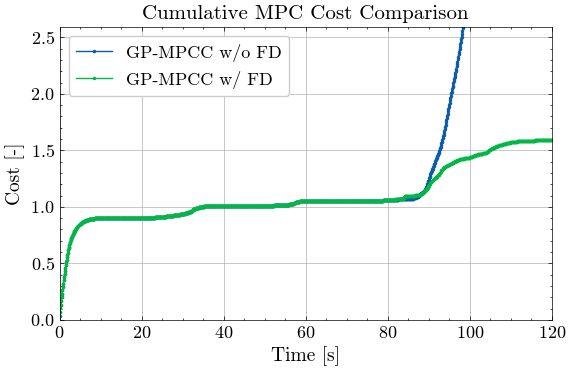

In [34]:
# Specify parameters (adjust these if necessary)
START_TIME = 0
END_TIME = 120

# Create a figure for the comparison plot
plt.figure(figsize=(6,4))

# Define labels for each log file
labels = ['GP-MPCC w/o FD', 'GP-MPCC w/ FD']

# Iterate through each dataframe and plot the cumulative cost
for i, df in enumerate(df_list):
    if df is not None:
        # Drop rows with NaNs in 'mpc_cost' or 'Timestamp'
        df_clean = df[['Timestamp', 'mpc_cost']].dropna()
        
        # Optional modification to 'mpc_cost' if necessary
        df_clean['mpc_cost'] += 5e-3 * 0.2
        
        # Compute cumulative cost
        df_clean['cumulative_cost'] = df_clean['mpc_cost'].cumsum()
        
        # Filter based on START_TIME and END_TIME
        if START_TIME is not None:
            df_clean = df_clean[df_clean['Timestamp'] >= START_TIME]
        if END_TIME is not None:
            max_timestamp = df_clean['Timestamp'].max()
            if END_TIME > max_timestamp:
                warnings.warn(f"Specified end_time {END_TIME} exceeds the maximum timestamp {max_timestamp}. Ignoring end_time filter.")
            else:
                df_clean = df_clean[df_clean['Timestamp'] <= END_TIME]

        # Plot the cumulative cost with the same style as your first notebook
        plt.plot(df_clean['Timestamp'], df_clean['cumulative_cost'], label=labels[i], marker='.', markersize=3, linewidth=1)

# Labels and title
plt.xlabel('Time [s]')
plt.ylabel('Cost [-]')
plt.title('Cumulative MPC Cost Comparison')
plt.legend(loc='best', facecolor='white', framealpha=1, frameon=True)
plt.grid(True)
plt.xlim((START_TIME, END_TIME))
plt.ylim(bottom=0, top=df_clean['cumulative_cost'].max()+ 1)

# Adjust layout to prevent label clipping
plt.tight_layout()

plt.savefig("case2/case2_cumulative_cost.svg", format="svg")
plt.savefig("case2/case2_cumulative_cost.pdf", format="pdf")


In [35]:
# Specify parameters (adjust these if necessary)
START_TIME = 0
END_TIME = 80

# Define labels for each log file
labels = ['GP-MPCC w/o Failure Detection', 'GP-MPCC w/ Failure Detection']

# Initialize an empty list to store the results
results = []

# Iterate through each dataframe and compute the required metrics
for i, df in enumerate(df_list):
    if df is not None:
        # Drop rows with NaNs in the relevant columns
        df_clean = df[['Timestamp', 'tracking_error', 'attitude_error', 'mpc_cost']].dropna()
        
        # Optional modification to 'mpc_cost' if necessary
        df_clean['mpc_cost'] += 5e-2 * 0.2
        
        # Filter based on START_TIME and END_TIME
        if START_TIME is not None:
            df_clean = df_clean[df_clean['Timestamp'] >= START_TIME]
        if END_TIME is not None:
            max_timestamp = df_clean['Timestamp'].max()
            if END_TIME > max_timestamp:
                warnings.warn(f"Specified end_time {END_TIME} exceeds the maximum timestamp {max_timestamp}. Ignoring end_time filter.")
            else:
                df_clean = df_clean[df_clean['Timestamp'] <= END_TIME]
        
        # Calculate the metrics
        mean_tracking_error = df_clean['tracking_error'].mean()
        mean_attitude_error = df_clean['attitude_error'].mean()
        cumulative_mpc_cost = df_clean['mpc_cost'].cumsum().iloc[-1]  # Get final cumulative MPC cost
        
        # Append the results for this configuration
        results.append({
            'Configuration': labels[i],
            'Mean Tracking Error': mean_tracking_error,
            'Mean Attitude Error': mean_attitude_error,
            'Cumulative MPC Cost': cumulative_mpc_cost
        })

# Convert the results to a pandas DataFrame
comparison_df = pd.DataFrame(results)

# Display the table
print(comparison_df)

# Optionally, display the DataFrame as a LaTeX table
latex_table = comparison_df.to_latex(index=False, float_format="%.3f")
print(latex_table)

                   Configuration  Mean Tracking Error  Mean Attitude Error  \
0  GP-MPCC w/o Failure Detection             0.026353              7.03435   
1   GP-MPCC w/ Failure Detection             0.026353              7.03435   

    Cumulative MPC Cost  
0  [[8.26853531149404]]  
1  [[8.26853531149404]]  
\begin{tabular}{lrrl}
\toprule
Configuration & Mean Tracking Error & Mean Attitude Error & Cumulative MPC Cost \\
\midrule
GP-MPCC w/o Failure Detection & 0.026 & 7.034 & [[8.26853531]] \\
GP-MPCC w/ Failure Detection & 0.026 & 7.034 & [[8.26853531]] \\
\bottomrule
\end{tabular}



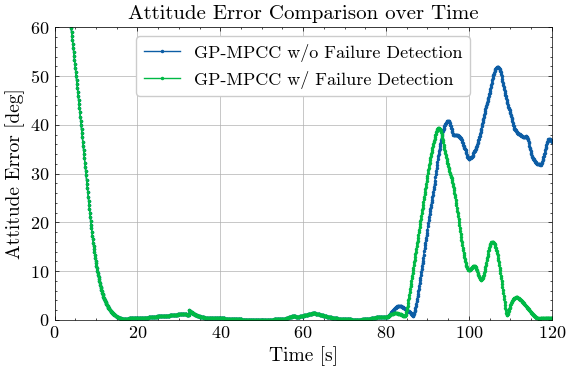

In [36]:
# %% [markdown]
# ## Compare Attitude Error Over Time for Multiple Logs

# %%
# Specify parameters (adjust these if necessary)
START_TIME = 0
END_TIME = 120

# Create a figure for the comparison plot
plt.figure(figsize=(6,4))

# Define labels for each log file
labels = ['GP-MPCC w/o Failure Detection', 'GP-MPCC w/ Failure Detection']

# Iterate through each dataframe and plot the attitude error over time
for i, df in enumerate(df_list):
    START_TIME = 0
    END_TIME = 120
    if df is not None:
        # Drop rows with NaNs in 'attitude_error' or 'Timestamp'
        df_clean = df[['Timestamp', 'attitude_error']].dropna()

        # Filter based on START_TIME and END_TIME
        if START_TIME is not None:
            df_clean = df_clean[df_clean['Timestamp'] >= START_TIME]
        if END_TIME is not None:
            max_timestamp = df_clean['Timestamp'].max()
            if END_TIME > max_timestamp:
                warnings.warn(f"Specified end_time {END_TIME} exceeds the maximum timestamp {max_timestamp}. Ignoring end_time filter.")
            else:
                df_clean = df_clean[df_clean['Timestamp'] <= END_TIME]

        # Plot the attitude error with the same style as your first notebook
        plt.plot(df_clean['Timestamp'], df_clean['attitude_error'], label=labels[i], marker='.', markersize=3, linewidth=1)

# Labels and title
plt.xlabel('Time [s]')
plt.ylabel('Attitude Error [deg]')
plt.title('Attitude Error Comparison over Time')
plt.legend(loc='best', facecolor='white', framealpha=1, frameon=True)
plt.grid(True)
plt.xlim((START_TIME, END_TIME))
plt.ylim(bottom=0, top=60)

# Adjust layout to prevent label clipping
plt.tight_layout()

plt.savefig("case2/case2_attitude_error.svg", format="svg")
plt.savefig("case2/case2_attitude_error.pdf", format="pdf")


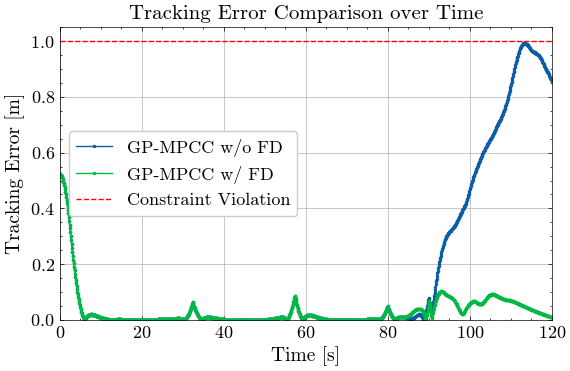

In [37]:
# %% [markdown]
# ## Compare Tracking Error Over Time for Multiple Logs

# %%
# Specify parameters (adjust these if necessary)
START_TIME = 0
END_TIME = 120

# Create a figure for the comparison plot
plt.figure(figsize=(6,4))

# Define labels for each log file
labels = ['GP-MPCC w/o FD', 'GP-MPCC w/ FD']

# Iterate through each dataframe and plot the tracking error over time
for i, df in enumerate(df_list):
    START_TIME = 0
    END_TIME = 120
    if df is not None:
        # Drop rows with NaNs in 'tracking_error' or 'Timestamp'
        df_clean = df[['Timestamp', 'tracking_error']].dropna()
        
        # Filter based on START_TIME and END_TIME
        if START_TIME is not None:
            df_clean = df_clean[df_clean['Timestamp'] >= START_TIME]
        if END_TIME is not None:
            max_timestamp = df_clean['Timestamp'].max()
            if END_TIME > max_timestamp:
                warnings.warn(f"Specified end_time {END_TIME} exceeds the maximum timestamp {max_timestamp}. Ignoring end_time filter.")
            else:
                df_clean = df_clean[df_clean['Timestamp'] <= END_TIME]

        # Plot the tracking error with the same style as your attitude error plot
        plt.plot(df_clean['Timestamp'], df_clean['tracking_error'], label=labels[i], marker='.', markersize=3, linewidth=1)

# Add the red dashed horizontal line at 1m for Constraint Violation
plt.axhline(y=1, color='red', linestyle='--', label='Constraint Violation')

# Labels and title
plt.xlabel('Time [s]')
plt.ylabel('Tracking Error [m]')
plt.title('Tracking Error Comparison over Time')
plt.legend(loc='best', facecolor='white', framealpha=1, frameon=True)
plt.grid(True)
plt.xlim((START_TIME, END_TIME))
plt.ylim((0, 1.05))

# Adjust layout to prevent label clipping
plt.tight_layout()

plt.savefig("case2/case2_tracking_error.svg", format="svg")
plt.savefig("case2/case2_tracking_error.pdf", format="pdf")

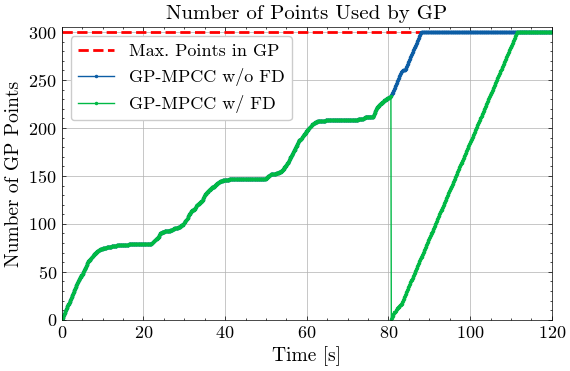

In [38]:
# %% [markdown]
# ## Compare Tracking Error Over Time for Multiple Logs

# %%
# Specify parameters (adjust these if necessary)
START_TIME = 0
END_TIME = 120

# Create a figure for the comparison plot
plt.figure(figsize=(6,4))

# Add the red dashed horizontal line at 1m for Constraint Violation
plt.axhline(y=300, color='red', linestyle='--', label='Max. Points in GP', linewidth=2)

# Define labels for each log file
labels = ['GP-MPCC w/o FD', 'GP-MPCC w/ FD']

# Iterate through each dataframe and plot the tracking error over time
for i, df in enumerate(df_list):
    START_TIME = 0
    END_TIME = 120
    if df is not None:
        # Drop rows with NaNs in 'tracking_error' or 'Timestamp'
        df_clean = df[['Timestamp', 'n_points_GP']].dropna()
        
        # Filter based on START_TIME and END_TIME
        if START_TIME is not None:
            df_clean = df_clean[df_clean['Timestamp'] >= START_TIME]
        if END_TIME is not None:
            max_timestamp = df_clean['Timestamp'].max()
            if END_TIME > max_timestamp:
                warnings.warn(f"Specified end_time {END_TIME} exceeds the maximum timestamp {max_timestamp}. Ignoring end_time filter.")
            else:
                df_clean = df_clean[df_clean['Timestamp'] <= END_TIME]

        # Plot the tracking error with the same style as your attitude error plot
        plt.plot(df_clean['Timestamp'], df_clean['n_points_GP'], label=labels[i], marker='.', markersize=3, linewidth=1)

# Labels and title
plt.xlabel('Time [s]')
plt.ylabel('Number of GP Points')
plt.title('Number of Points Used by GP')
plt.legend(loc='best', facecolor='white', framealpha=1, frameon=True)
plt.grid(True)
plt.xlim((START_TIME, END_TIME))
plt.ylim((0,305))

# Adjust layout to prevent label clipping
plt.tight_layout()

plt.savefig("case2/case2_n_points_GP.svg", format="svg")
plt.savefig("case2/case2_n_points_GP.pdf", format="pdf")

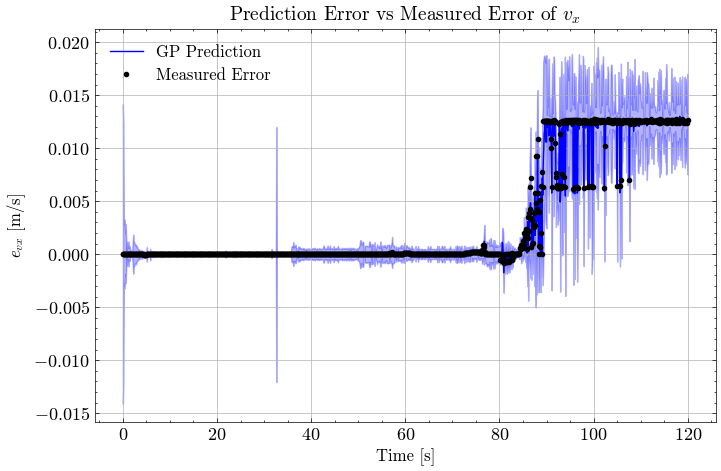

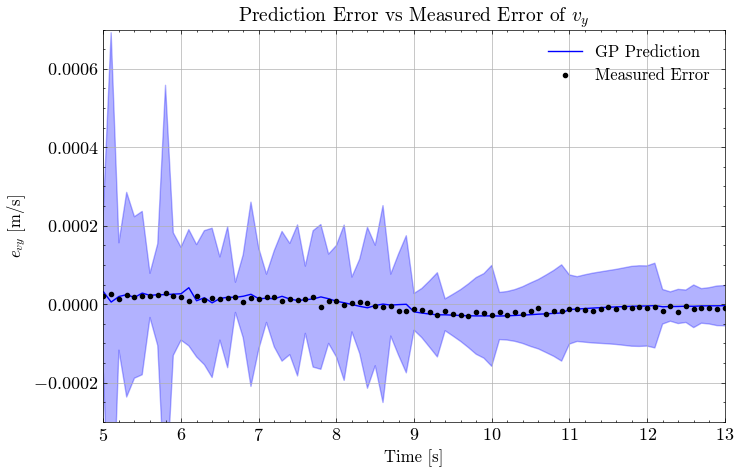

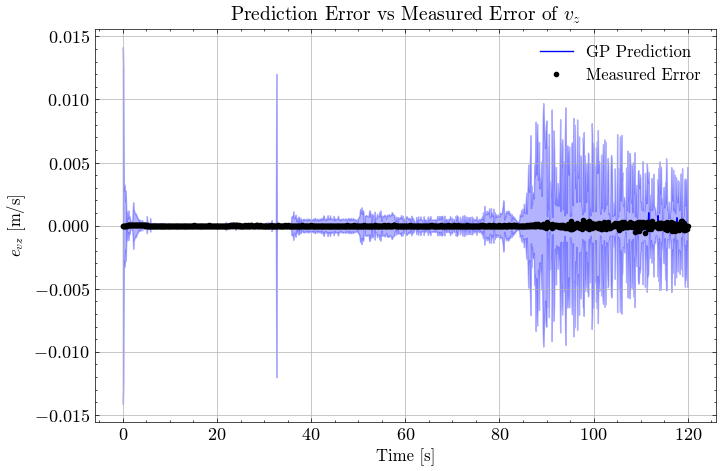

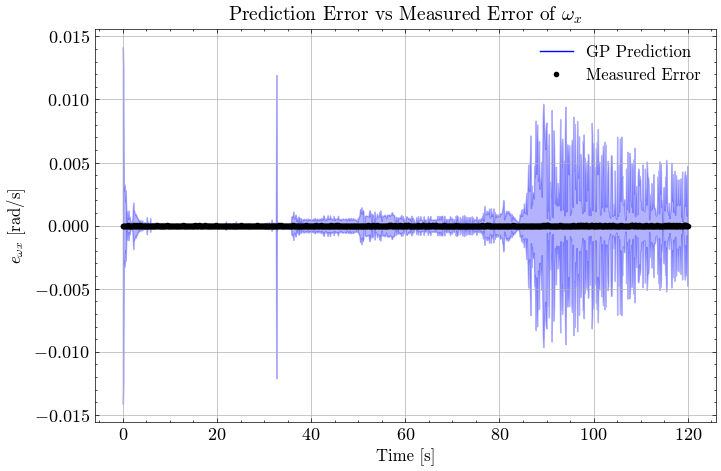

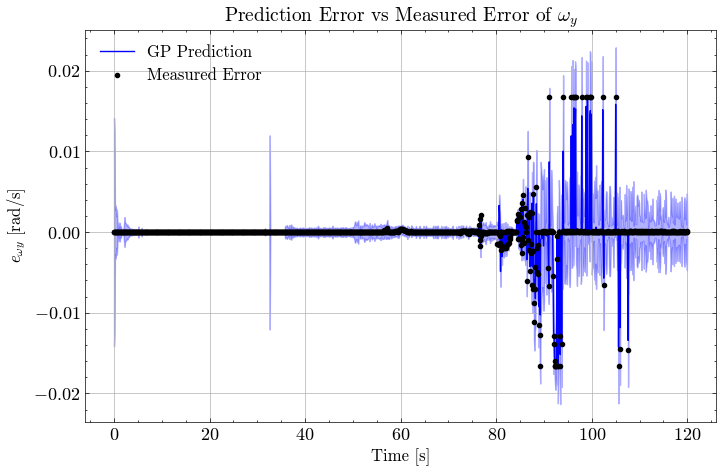

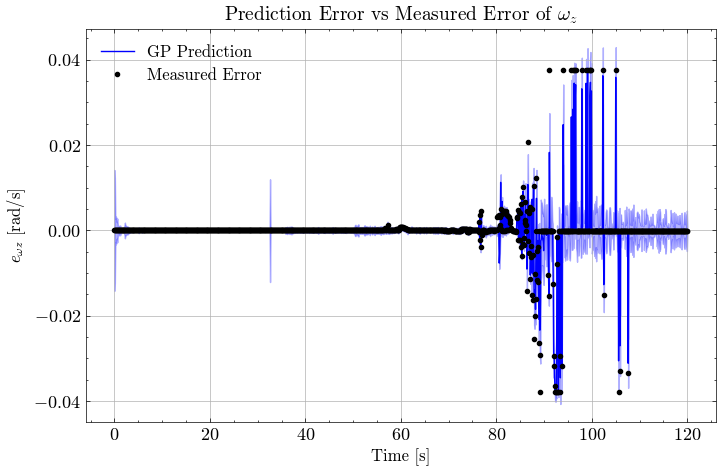

In [46]:
# Assuming your DataFrame is named df
# NOTE: Specify paramters here if you want
START_TIME = 0
END_TIME = 120

def plot_gp_component(df_clean, index, title, ylabel):
    """
    Plots the GP prediction and confidence interval for a specific component.
    """

    # Extract the specific component for each DataFrame column
    gp_pred_component = df_clean['gp_pred'].apply(lambda x: x[index])
    gp_GT_component = df_clean['gp_GT'].apply(lambda x: x[index])
    gp_upper_component = df_clean['gp_upper'].apply(lambda x: x[index])
    gp_lower_component = df_clean['gp_lower'].apply(lambda x: x[index])

    # Plot
    plt.figure(figsize=(7.5, 5))
    plt.plot(df_clean['Timestamp'], gp_pred_component, "b", label="GP Prediction")  # Mean prediction in blue
    plt.fill_between(df_clean['Timestamp'], gp_lower_component, gp_upper_component, alpha=0.3, color='blue')  # Confidence interval
    plt.plot(df_clean['Timestamp'], gp_GT_component, "k.", label="Measured Error")  # Ground truth data in black

    plt.xlabel("Time [s]", fontsize=12)
    plt.ylabel(ylabel, fontsize=12)
    plt.title(title, fontsize=14)
    plt.legend(loc='best', fontsize=12)
    plt.grid(True)
    plt.tight_layout()

    plt.show()

# Drop rows with NaNs in 'e_gp', 'e_nom', or 'Timestamp'

df_clean = df_list[0][['Timestamp', 'gp_pred', 'gp_GT', 'gp_upper', 'gp_lower']].dropna()

# Filter based on start_time and end_time if provideds
if START_TIME is not None:
    df_clean = df_clean[df_clean['Timestamp'] >= START_TIME]
if END_TIME is not None:
    if END_TIME > (max_timestamp := df_clean['Timestamp'].max()):
        warnings.warn(f"Specified end_time {END_TIME} exceeds the maximum timestamp {max_timestamp}. Ignoring end_time filter.")
    else:
        df_clean = df_clean[df_clean['Timestamp'] <= END_TIME]


# Define the components and titles for each component
components = [
    (0, r"Prediction Error vs Measured Error of $v_{x}$", r"$e_{vx}$ [m/s]"),
    (1, r"Prediction Error vs Measured Error of $v_{y}$", r"$e_{vy}$ [m/s]"),
    (2, r"Prediction Error vs Measured Error of $v_{z}$", r"$e_{vz}$ [m/s]"),
    (3, r"Prediction Error vs Measured Error of $\omega_{x}$", r"$e_{\omega x}$ [rad/s]"),
    (4, r"Prediction Error vs Measured Error of $\omega_{y}$", r"$e_{\omega y}$ [rad/s]"),
    (5, r"Prediction Error vs Measured Error of $\omega_{z}$", r"$e_{\omega z}$ [rad/s]"),
]

# Loop through each component and plot
for index, title, ylabel in components:
    plot_gp_component(df_clean, index, title, ylabel)

Loading log files from directory: /media/ahansson/2884-8728/logs/2024-10-24_16-21-52


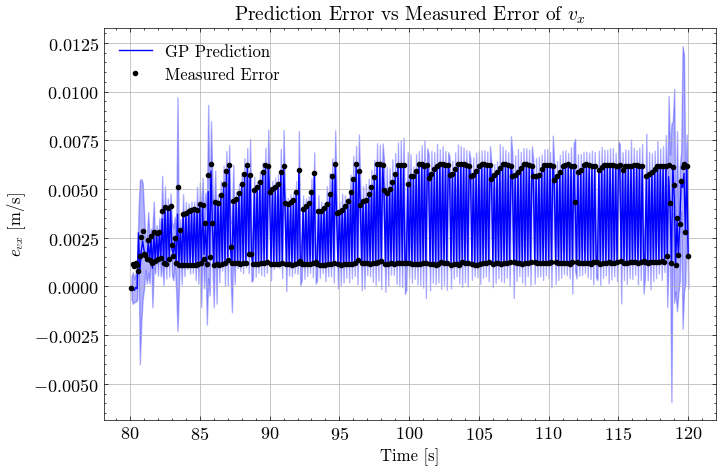

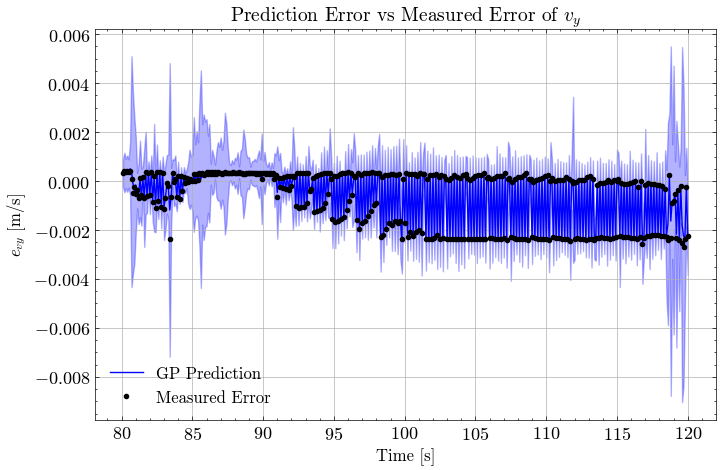

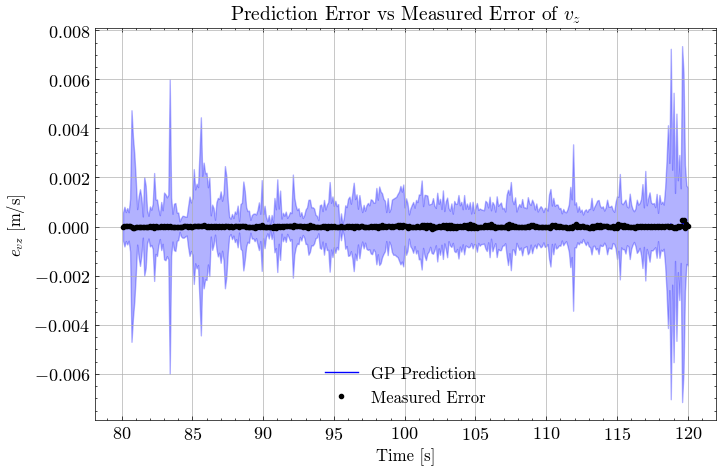

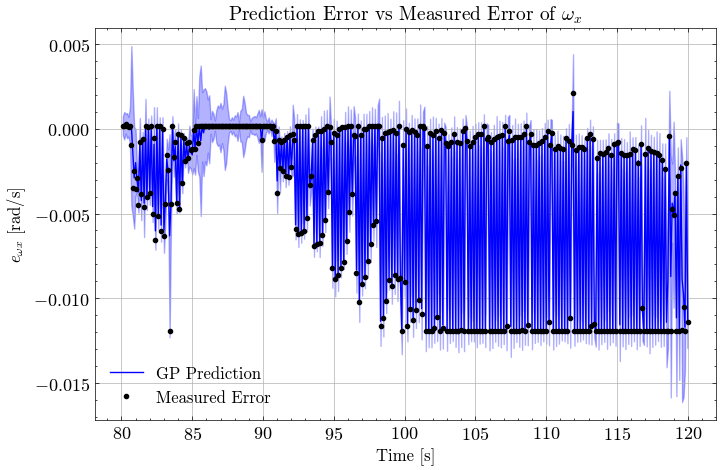

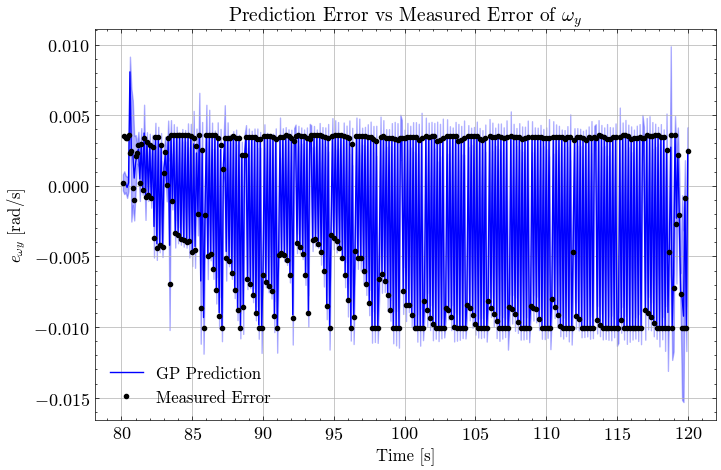

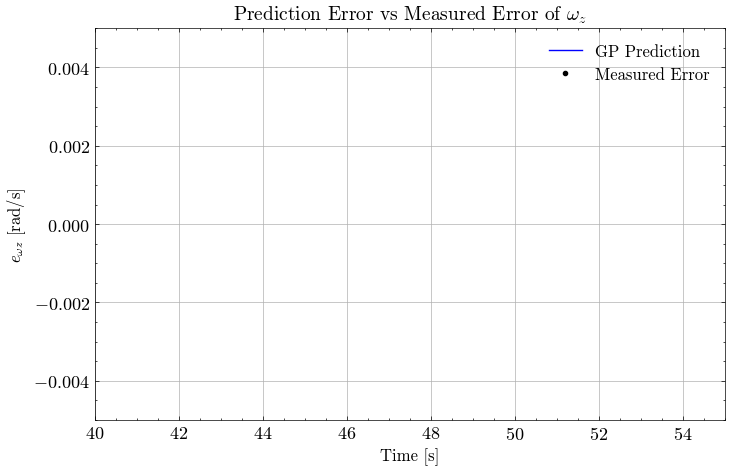

In [44]:
# Assuming your DataFrame is named df
# NOTE: Specify paramters here if you want
START_TIME = 80
END_TIME = 120

def plot_gp_component(df_clean, index, title, ylabel):
    """
    Plots the GP prediction and confidence interval for a specific component.
    """

    # Extract the specific component for each DataFrame column
    gp_pred_component = df_clean['gp_pred'].apply(lambda x: x[index])
    gp_GT_component = df_clean['gp_GT'].apply(lambda x: x[index])
    gp_upper_component = df_clean['gp_upper'].apply(lambda x: x[index])
    gp_lower_component = df_clean['gp_lower'].apply(lambda x: x[index])

    # Plot
    plt.figure(figsize=(7.5, 5))
    plt.plot(df_clean['Timestamp'], gp_pred_component, "b", label="GP Prediction")  # Mean prediction in blue
    plt.fill_between(df_clean['Timestamp'], gp_lower_component, gp_upper_component, alpha=0.3, color='blue')  # Confidence interval
    plt.plot(df_clean['Timestamp'], gp_GT_component, "k.", label="Measured Error")  # Ground truth data in black

    plt.xlabel("Time [s]", fontsize=12)
    plt.ylabel(ylabel, fontsize=12)
    plt.title(title, fontsize=14)
    plt.legend(loc='best', fontsize=12)
    plt.grid(True)
    plt.tight_layout()

    # if index == 0:
    #     plt.xlim((40, 55))
    #     plt.ylim((-0.003, 0.003))

    if index == 5:
        plt.xlim((40, 55))
        plt.ylim((-0.005, 0.005))

    plt.show()
    

# Drop rows with NaNs in 'e_gp', 'e_nom', or 'Timestamp'

df_clean = df_list[1][['Timestamp', 'gp_pred', 'gp_GT', 'gp_upper', 'gp_lower']].dropna()

# Filter based on start_time and end_time if provideds
if START_TIME is not None:
    df_clean = df_clean[df_clean['Timestamp'] >= START_TIME]
if END_TIME is not None:
    if END_TIME > (max_timestamp := df_clean['Timestamp'].max()):
        warnings.warn(f"Specified end_time {END_TIME} exceeds the maximum timestamp {max_timestamp}. Ignoring end_time filter.")
    else:
        df_clean = df_clean[df_clean['Timestamp'] <= END_TIME]


# Define the components and titles for each component
components = [
    (0, r"Prediction Error vs Measured Error of $v_{x}$", r"$e_{vx}$ [m/s]"),
    (1, r"Prediction Error vs Measured Error of $v_{y}$", r"$e_{vy}$ [m/s]"),
    (2, r"Prediction Error vs Measured Error of $v_{z}$", r"$e_{vz}$ [m/s]"),
    (3, r"Prediction Error vs Measured Error of $\omega_{x}$", r"$e_{\omega x}$ [rad/s]"),
    (4, r"Prediction Error vs Measured Error of $\omega_{y}$", r"$e_{\omega y}$ [rad/s]"),
    (5, r"Prediction Error vs Measured Error of $\omega_{z}$", r"$e_{\omega z}$ [rad/s]"),
]

# Loop through each component and plot
for index, title, ylabel in components:
    plot_gp_component(df_clean, index, title, ylabel)

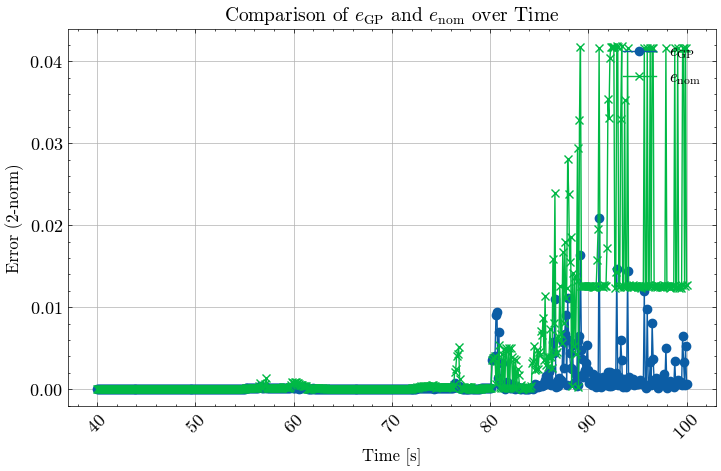

Quantity  Average  Std Dev          Min      Max
    e_gp 0.000722 0.002023 4.028446e-06 0.020874
   e_nom 0.004509 0.009286 1.386540e-07 0.041783


In [41]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming your DataFrame is named df
# NOTE: Specify paramters here if you want
START_TIME = 40
END_TIME = 100

# Drop rows with NaNs in 'e_gp', 'e_nom', or 'Timestamp'
df_clean = df_list[0][['Timestamp', 'e_gp', 'e_nom']].dropna()

# Filter based on start_time and end_time if provided
if START_TIME is not None:
    df_clean = df_clean[df_clean['Timestamp'] >= START_TIME]
if END_TIME is not None:
    if END_TIME > (max_timestamp := df_clean['Timestamp'].max()):
        warnings.warn(f"Specified end_time {END_TIME} exceeds the maximum timestamp {max_timestamp}. Ignoring end_time filter.")
    else:
        df_clean = df_clean[df_clean['Timestamp'] <= END_TIME]

# Plotting the values
plt.figure(figsize=(7.5, 5))
plt.plot(df_clean['Timestamp'], df_clean['e_gp'], label=r'$e_{\text{GP}}$', marker='o')
plt.plot(df_clean['Timestamp'], df_clean['e_nom'], label=r'$e_{\text{nom}}$', marker='x')
plt.title(r'Comparison of $e_{\text{GP}}$ and $e_{\text{nom}}$ over Time', fontsize=14)
plt.xlabel(r'Time [s]', fontsize=12)
plt.ylabel(r'Error (2-norm)', fontsize=12)
plt.legend(loc='upper right', fontsize=12)
plt.grid(True)
plt.xticks(rotation=45)  # Rotate x-axis labels if needed
plt.tight_layout()  # Adjust layout to prevent clipping of labels
plt.show()

# Create a table
# Calculate statistics for e_gp and e_nom
stats = {
    'Quantity': ['e_gp', 'e_nom'],
    'Average': [df_clean['e_gp'].mean(), df_clean['e_nom'].mean()],
    'Std Dev': [df_clean['e_gp'].std(), df_clean['e_nom'].std()],
    'Min': [df_clean['e_gp'].min(), df_clean['e_nom'].min()],
    'Max': [df_clean['e_gp'].max(), df_clean['e_nom'].max()]
}

# Create a pandas DataFrame to display the statistics in a table
stats_df = pd.DataFrame(stats)
print(stats_df.to_string(index=False))

# Generate LaTeX table
latex_table = stats_df.to_latex(index=False, float_format="%.3f")

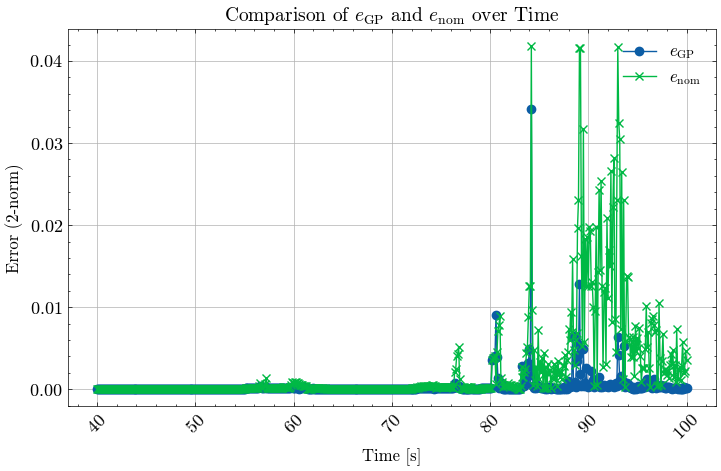

Quantity  Average  Std Dev          Min      Max
    e_gp 0.000384 0.001697 4.028446e-06 0.034183
   e_nom 0.002461 0.005921 1.386540e-07 0.041765


In [42]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming your DataFrame is named df
# NOTE: Specify paramters here if you want
START_TIME = 40
END_TIME = 100

# Drop rows with NaNs in 'e_gp', 'e_nom', or 'Timestamp'
df_clean = df_list[1][['Timestamp', 'e_gp', 'e_nom']].dropna()

# Filter based on start_time and end_time if provided
if START_TIME is not None:
    df_clean = df_clean[df_clean['Timestamp'] >= START_TIME]
if END_TIME is not None:
    if END_TIME > (max_timestamp := df_clean['Timestamp'].max()):
        warnings.warn(f"Specified end_time {END_TIME} exceeds the maximum timestamp {max_timestamp}. Ignoring end_time filter.")
    else:
        df_clean = df_clean[df_clean['Timestamp'] <= END_TIME]

# Plotting the values
plt.figure(figsize=(7.5, 5))
plt.plot(df_clean['Timestamp'], df_clean['e_gp'], label=r'$e_{\text{GP}}$', marker='o')
plt.plot(df_clean['Timestamp'], df_clean['e_nom'], label=r'$e_{\text{nom}}$', marker='x')
plt.title(r'Comparison of $e_{\text{GP}}$ and $e_{\text{nom}}$ over Time', fontsize=14)
plt.xlabel(r'Time [s]', fontsize=12)
plt.ylabel(r'Error (2-norm)', fontsize=12)
plt.legend(loc='upper right', fontsize=12)
plt.grid(True)
plt.xticks(rotation=45)  # Rotate x-axis labels if needed
plt.tight_layout()  # Adjust layout to prevent clipping of labels
plt.show()

# Create a table
# Calculate statistics for e_gp and e_nom
stats = {
    'Quantity': ['e_gp', 'e_nom'],
    'Average': [df_clean['e_gp'].mean(), df_clean['e_nom'].mean()],
    'Std Dev': [df_clean['e_gp'].std(), df_clean['e_nom'].std()],
    'Min': [df_clean['e_gp'].min(), df_clean['e_nom'].min()],
    'Max': [df_clean['e_gp'].max(), df_clean['e_nom'].max()]
}

# Create a pandas DataFrame to display the statistics in a table
stats_df = pd.DataFrame(stats)
print(stats_df.to_string(index=False))

# Generate LaTeX table
latex_table = stats_df.to_latex(index=False, float_format="%.3f")

In [43]:
# Create Logger object (needed to load data)
logger = Logger()

# Set names of the different logs
filename1 = "2024-10-21_16-05-59" # MPCC w/o Failure Detection
filename2 = "2024-10-21_16-11-46" # MPCC w/ Failure Detection


df1 = logger.load_log(filename1)[['Timestamp', 'n_points_GP', 'e_gp', 'e_nom', 'tracking_error', 'attitude_error', 'u_demanded', 'u_actual', 'mpc_cost', 'velocity', 'frames']].dropna().reset_index(drop=True)
df1['mpc_cost'] += 5e-3 * 0.2
df1['cumulative_cost'] = df1['mpc_cost'].cumsum()

df2 = logger.load_log(filename2)[['Timestamp', 'n_points_GP', 'e_gp', 'e_nom', 'tracking_error', 'attitude_error', 'u_demanded', 'u_actual', 'mpc_cost', 'velocity', 'frames']].dropna().reset_index(drop=True)
df2['mpc_cost'] += 5e-3 * 0.2
df2['cumulative_cost'] = df2['mpc_cost'].cumsum()

SyntaxError: 'return' outside function (1982955520.py, line 1)

In [ ]:
# # Load the rest of the data
# df_clean = df_list[0][['Timestamp', 'n_points_GP', 'e_gp', 'e_nom', 'tracking_error', 'attitude_error', 'u_demanded', 'u_actual', 'mpc_cost', 'velocity']].dropna().reset_index(drop=True)
# df_clean['mpc_cost'] += 5e-3 * 0.2
# df_clean['cumulative_cost'] = df_clean['mpc_cost'].cumsum()
# print(df_clean)

In [ ]:
# pass

# from matplotlib.animation import FuncAnimation
# from matplotlib.gridspec import GridSpec

# # Example DataFrame with video frames and timestamps
# timestamps = df_clean_video['Timestamp'].values
# n_points_GP = df_clean['n_points_GP'].values
# e_gp = df_clean['e_gp'].values
# e_nom = df_clean['e_nom'].values
# tracking_error = df_clean['tracking_error'].values
# attitude_error = df_clean['attitude_error'].values
# u_demanded = df_clean['u_demanded'].values
# u_actual = df_clean['u_actual'].values
# mpc_cost = df_clean['mpc_cost'].values
# cumulative_cost = df_clean['cumulative_cost'].values
# velocity = df_clean['velocity'].values

# # Extract data for a specific thruster
# thruster_idx = 0
# u_demanded_i = np.array([u[thruster_idx] for u in u_demanded])
# u_actual_i = np.array([u[thruster_idx] for u in u_actual])

# # Create the figure and GridSpec layout
# fig = plt.figure(figsize=(19.2, 10.8), dpi=200)
# gs = GridSpec(14, 25)  # Create a grid with 6 rows and 6 columns

# # Subplot for video frames (large top-left area)
# ax_video = fig.add_subplot(gs[0:9, 0:16])  # Spanning 9 rows and 16 columns (more horizontal space)
# ax_video.axis('off')  # Remove axes for the video

# # Two smaller plots stacked to the right of the video
# ax_plot_right_top = fig.add_subplot(gs[0:4, 17:25])  # First small plot to the right of the video
# ax_plot_right_top.set_title("Prediction Error")

# ax_plot_right_bottom = fig.add_subplot(gs[5:9, 17:25])  # Second small plot to the right of the video
# ax_plot_right_bottom.set_title("Number of Training Points in GP")

# # Two plots side by side below the video (bottom left)
# ax_bottom_left_1 = fig.add_subplot(gs[10:14, 0:7])  # First plot below the video
# ax_bottom_left_1.set_title("Lateral Tracking Error")

# ax_bottom_left_2 = fig.add_subplot(gs[10:14, 9:16])  # Second plot below the video
# ax_bottom_left_2.set_title("Attitude Error")

# # One plot in the bottom right corner (below the stacked plots)
# ax_bottom_right = fig.add_subplot(gs[10:14, 17:25])  # Plot in the bottom right corner
# ax_bottom_right.set_title(f"Demanded vs. Actual Thrust of Thruster {thruster_idx}")


# def get_sliding_window_idx(frame, window_size):
#     return max(0, frame - window_size), min(frame + 1, len(df_clean_video))


# # Update function for each frame
# def update(frame):
#     # Get the current video frame from the DataFrame
#     video_frame = df_clean_video['frames'].iloc[frame]

#     # Update video subplot
#     ax_video.clear()
#     ax_video.axis('off')  # Hide axes for the video
#     if video_frame is not None:
#         ax_video.imshow(video_frame)  # Display video frame

#     # Update the right top plot
#     start_idx, end_idx = get_sliding_window_idx(frame, 200)
#     ax_plot_right_top.clear()
#     ax_plot_right_top.set_title("Prediction Error")
#     ax_plot_right_top.plot(timestamps[start_idx:end_idx], e_gp[start_idx:end_idx], lw=2, label=r'$e_{\text{GP}}$')
#     ax_plot_right_top.plot(timestamps[start_idx:end_idx], e_nom[start_idx:end_idx], lw=2, label=r'$e_{\text{nom}}$')
#     ax_plot_right_top.set_xlim(timestamps[start_idx], timestamps[end_idx])
#     ax_plot_right_top.set_xlabel("Time [s]")
#     ax_plot_right_top.set_ylabel(r"Error $l_2$ norm")
#     ax_plot_right_top.set_ylim(bottom=0)
#     ax_plot_right_top.legend(loc='best')

#     # Update the right bottom plot
#     start_idx, end_idx = get_sliding_window_idx(frame, 500)
#     ax_plot_right_bottom.clear()
#     ax_plot_right_bottom.set_title("Number of Training Points in GP")
#     ax_plot_right_bottom.plot(timestamps[start_idx:end_idx], n_points_GP[start_idx:end_idx], lw=2, marker='.')
#     ax_plot_right_bottom.set_xlim(timestamps[start_idx], timestamps[end_idx])
#     ax_plot_right_bottom.set_xlabel("Time [s]")
#     ax_plot_right_bottom.set_ylabel("Number of GP points")
#     ax_bottom_right.set_ylim((0,300))

#     # Update bottom left plot 1
#     start_idx, end_idx = get_sliding_window_idx(frame, 100)
#     ax_bottom_left_1.clear()
#     ax_bottom_left_1.set_title("Lateral Tracking Error")
#     ax_bottom_left_1.plot(timestamps[start_idx:end_idx], tracking_error[start_idx:end_idx], lw=2)
#     ax_bottom_left_1.set_xlim(timestamps[start_idx], timestamps[end_idx])
#     ax_bottom_left_1.set_xlabel("Time [s]")
#     ax_bottom_left_1.set_ylabel("Error [m]")
#     ax_bottom_left_1.set_ylim(bottom=0)

#     # Update bottom left plot 2
#     ax_bottom_left_2.clear()
#     ax_bottom_left_2.set_title("Velocity")
#     ax_bottom_left_2.plot(timestamps[start_idx:end_idx], velocity[start_idx:end_idx], lw=2)
#     ax_bottom_left_2.set_xlim(timestamps[start_idx], timestamps[end_idx])
#     ax_bottom_left_2.set_xlabel("Time [s]")
#     ax_bottom_left_2.set_ylabel("Velocity [m/s]")
#     ax_bottom_left_2.set_ylim(bottom=0, top= 0.26)
#     ax_bottom_left_2.axhline(y=0.25, color='red', linestyle='--', label='Upper Bound')
#     ax_bottom_left_2.legend(loc='best')

#     # Update bottom right plot
#     start_idx, end_idx = get_sliding_window_idx(frame, 500)
#     ax_bottom_right.clear()
#     ax_bottom_right.set_title(f"Cumulative cost")
#     ax_bottom_right.plot(timestamps[start_idx:end_idx], cumulative_cost[start_idx:end_idx], lw=2)
#     ax_bottom_right.set_xlim(timestamps[start_idx], timestamps[end_idx])
#     ax_bottom_right.set_xlabel("Time [s]")
#     ax_bottom_right.set_ylabel("Cost [-]")
#     ax_bottom_right.set_ylim(bottom=0)
#     ax_plot_right_top.legend(loc='best')

# # Create the animation using FuncAnimation
# ani = FuncAnimation(fig, update, frames=10-1, repeat=False)

# # Save the animation as a video file
# ani.save('output_video.mp4', fps=30, extra_args=['-vcodec', 'libx264'])

# print("Video saved as output_video.mp4")

In [ ]:
from matplotlib.animation import FuncAnimation
from matplotlib.gridspec import GridSpec

# Example DataFrame with video frames and timestamps
timestamps_1 = df1['Timestamp'].values
n_points_GP_1 = df1['n_points_GP'].values
e_gp_1 = df1['e_gp'].values
e_nom_1 = df1['e_nom'].values
tracking_error_1 = df1['tracking_error'].values
attitude_error_1 = df1['attitude_error'].values
u_demanded_1 = df1['u_demanded'].values
u_actual_1 = df1['u_actual'].values
mpc_cost_1 = df1['mpc_cost'].values
cumulative_cost_1 = df1['cumulative_cost'].values
velocity_1 = df1['velocity'].values

timestamps_2 = df2['Timestamp'].values
n_points_GP_2 = df2['n_points_GP'].values
e_gp_2 = df2['e_gp'].values
e_nom_2 = df2['e_nom'].values
tracking_error_2 = df2['tracking_error'].values
attitude_error_2 = df2['attitude_error'].values
u_demanded_2 = df2['u_demanded'].values
u_actual_2 = df2['u_actual'].values
mpc_cost_2 = df2['mpc_cost'].values
cumulative_cost_2 = df2['cumulative_cost'].values
velocity_2 = df2['velocity'].values

# Extract data for a specific thruster
# thruster_idx = 0
# u_demanded_i = np.array([u[thruster_idx] for u in u_demanded])
# u_actual_i = np.array([u[thruster_idx] for u in u_actual])

# Create the figure and GridSpec layout
fig = plt.figure(figsize=(16.5, 8), dpi=200)
gs = GridSpec(16, 33)  # Create a grid with 6 rows and 6 columns

# Subplot for video frames (large top-left area)
ax_video1 = fig.add_subplot(gs[0:9, 0:16])  # Spanning 9 rows and 16 columns (more horizontal space)
ax_video1.axis('off')  # Remove axes for the video

# Subplot for video frames (large top-left area)
ax_video2 = fig.add_subplot(gs[0:9, 17:33])  # Spanning 9 rows and 16 columns (more horizontal space)
ax_video2.axis('off')  # Remove axes for the video

ax_plot_left = fig.add_subplot(gs[10:16, 0:9])
ax_plot_left.set_title("Tracking Error")
ax_plot_left.grid(True)

ax_plot_middle = fig.add_subplot(gs[10:16, 12:21])
ax_plot_middle.set_title("Points in GP")
ax_plot_left.grid(True)

ax_plot_right = fig.add_subplot(gs[10:16, 24:33])
ax_plot_right.set_title("Cumulative Cost")
ax_plot_left.grid(True)



def get_sliding_window_idx(frame, window_size):
    return max(0, frame - window_size), min(frame + 1, len(df1))


# Update function for each frame
def update(frame):
    # Get the current video frame from the DataFrame
    video_frame1 = df1['frames'].iloc[frame]
    video_frame2 = df2['frames'].iloc[frame]

    # Update video subplot
    ax_video1.clear()
    ax_video1.axis('off')  # Hide axes for the video
    ax_video1.set_title("GP-MPCC w/o FD")
    if video_frame1 is not None:
        ax_video1.imshow(video_frame1)  # Display video frame

    ax_video2.clear()
    ax_video2.axis('off')  # Hide axes for the video
    ax_video2.set_title("GP-MPCC w/ FD")
    if video_frame2 is not None:
        ax_video2.imshow(video_frame2)


    # Update left plot
    start_idx, end_idx = get_sliding_window_idx(frame, 100)
    ax_plot_left.clear()
    ax_plot_left.axhline(y=1.0, color='red', linestyle='--', linewidth = 1.8)
    ax_plot_left.axvline(x=10, label='Failure 1', color='#8A2BE2', linewidth = 1.8)
    ax_plot_left.axvline(x=60, label='Failure 2', color='#8A2BE2', linewidth = 1.8)
    ax_plot_left.set_title("Lateral Tracking Error")
    ax_plot_left.plot(timestamps_1[start_idx:end_idx], tracking_error_1[start_idx:end_idx], lw=2)
    ax_plot_left.plot(timestamps_2[start_idx:end_idx], tracking_error_2[start_idx:end_idx], lw=2)
    ax_plot_left.grid(True)
    ax_plot_left.set_xlim(timestamps_1[start_idx], timestamps_1[end_idx])
    ax_plot_left.set_xlabel("Time [s]")
    ax_plot_left.set_ylabel("Error [m]")
    ax_plot_left.set_ylim((0, 1.03))

    # Middle plot
    start_idx, end_idx = get_sliding_window_idx(frame, 500)
    ax_plot_middle.clear()
    ax_plot_middle.set_title("Training Points in GP")
    ax_plot_middle.axhline(y=300, color='red', linestyle='--', linewidth = 1.8)
    ax_plot_middle.axvline(x=10, label='Failure 1', color='#8A2BE2', linewidth = 1.8)
    ax_plot_middle.axvline(x=60, label='Failure 2', color='#8A2BE2', linewidth = 1.8)
    ax_plot_middle.plot(timestamps_1[start_idx:end_idx], n_points_GP_1[start_idx:end_idx], lw=2, marker='.')
    ax_plot_middle.plot(timestamps_2[start_idx:end_idx], n_points_GP_2[start_idx:end_idx], lw=2, marker='.')
    ax_plot_middle.grid(True)
    ax_plot_middle.set_xlim(timestamps_1[start_idx], timestamps_1[end_idx])
    ax_plot_middle.set_xlabel("Time [s]")
    ax_plot_middle.set_ylabel("Number of points")
    ax_plot_middle.set_ylim((0,305))

    # Right plot
    start_idx, end_idx = get_sliding_window_idx(frame, 500)
    ax_plot_right.clear()
    ax_plot_right.set_title(f"Cumulative cost")
    ax_plot_right.axvline(x=10, label='Failure 1', color='#8A2BE2', linewidth = 1.8)
    ax_plot_right.axvline(x=60, label='Failure 2', color='#8A2BE2', linewidth = 1.8)
    ax_plot_right.plot(timestamps_1[start_idx:end_idx], cumulative_cost_1[start_idx:end_idx], lw=2)
    ax_plot_right.plot(timestamps_2[start_idx:end_idx], cumulative_cost_2[start_idx:end_idx], lw=2)
    ax_plot_right.grid(True)
    ax_plot_right.set_xlim(timestamps_1[start_idx], timestamps_1[end_idx])
    ax_plot_right.set_xlabel("Time [s]")
    ax_plot_right.set_ylabel("Cost [-]")
    ax_plot_right.set_ylim(bottom=0)


# Create the animation using FuncAnimation
ani = FuncAnimation(fig, update, frames=length(df1)-1, repeat=False)

# Save the animation as a video file
ani.save('output_video_case2.mp4', fps=30, extra_args=['-vcodec', 'libx264'])

print("Video saved as output_video.mp4")

"2024-10-21_15-02-52"

Failure at 52s instead of 45. Also e-1 covariance and additional resiudal check in strategy.py